In [1]:
import sys
import shap

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("SHAP version:", shap.__version__)

Python executable: c:\Users\Shree\miniconda3\envs\churn-shap\python.exe
Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
SHAP version: 0.51.0


In [1]:
# ============================================
# BLOCK 1: Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Display SHAP version
print("SHAP Version:", shap.__version__)

SHAP Version: 0.51.0


In [4]:
# ============================================
# BLOCK 2: Load Final Model and SHAP Artifacts
# ============================================

import joblib

# Load final tuned XGBoost model
best_xgb_model = joblib.load(
    "models/final_xgboost_churn_model.pkl"
)

# Load processed test data
X_test_processed = joblib.load(
    "models/X_test_processed.pkl"
)

# Load test target
y_test = joblib.load(
    "models/y_test.pkl"
)

# Load feature names
feature_names = joblib.load(
    "models/feature_names.pkl"
)

# ============================================
# Verify Loaded Artifacts
# ============================================

print("Final XGBoost model loaded successfully!")
print("Model type:", type(best_xgb_model))

print("\nX_test_processed shape:", X_test_processed.shape)
print("y_test shape:", y_test.shape)
print("Number of feature names:", len(feature_names))

# Verify feature count
assert X_test_processed.shape[1] == len(feature_names), \
    "Mismatch between processed features and feature names!"

print("\nFeature count verification: PASSED")

Final XGBoost model loaded successfully!
Model type: <class 'xgboost.sklearn.XGBClassifier'>

X_test_processed shape: (1405, 45)
y_test shape: (1405,)
Number of feature names: 45

Feature count verification: PASSED


In [5]:
# ============================================
# BLOCK 2: Create SHAP TreeExplainer
# ============================================

# Create SHAP TreeExplainer for the final XGBoost model
shap_explainer = shap.TreeExplainer(best_xgb_model)

# Calculate SHAP values for the processed test data
shap_values = shap_explainer.shap_values(X_test_processed)

# ============================================
# Handle Different SHAP API Output Formats
# ============================================

# For binary classification, handle list output
if isinstance(shap_values, list):
    # Select SHAP values for Churn = 1
    shap_values = shap_values[1]

# Handle 3D NumPy array output
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Select SHAP values for Churn = 1
    shap_values = shap_values[:, :, 1]

# ============================================
# Verify SHAP Values
# ============================================

print("=" * 60)
print("SHAP VALUES VERIFICATION")
print("=" * 60)

print("\nX_test_processed shape:", X_test_processed.shape)
print("SHAP values shape:", shap_values.shape)
print("Number of feature names:", len(feature_names))

# Verify number of samples
assert shap_values.shape[0] == X_test_processed.shape[0], \
    "Mismatch between test samples and SHAP samples!"

# Verify number of features
assert shap_values.shape[1] == len(feature_names), \
    "Mismatch between SHAP features and feature_names!"

print("\nSample count verification: PASSED")
print("Feature count verification: PASSED")

print("\nSHAP values successfully calculated!")
print("SHAP values correspond to Churn = 1.")

SHAP VALUES VERIFICATION

X_test_processed shape: (1405, 45)
SHAP values shape: (1405, 45)
Number of feature names: 45

Sample count verification: PASSED
Feature count verification: PASSED

SHAP values successfully calculated!
SHAP values correspond to Churn = 1.


In [6]:
# ============================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

# Create DataFrame
shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

# Sort by importance in descending order
shap_importance_df = shap_importance_df.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# Display top 20 most important features
print("Top 20 Most Important Features Based on SHAP:")
print("=" * 60)

display(shap_importance_df.head(20))

Top 20 Most Important Features Based on SHAP:


,Feature,Mean_Absolute_SHAP
0,categorical__Contract_Month-to-month,0.699718
1,numerical__tenure,0.547852
2,categorical__InternetService_Fiber optic,0.313348
3,categorical__OnlineSecurity_No,0.284196
4,categorical__PaperlessBilling_Yes,0.220432
5,categorical__PaymentMethod_Electronic check,0.218668
6,categorical__Contract_Two year,0.211826
7,numerical__MonthlyCharges,0.210203
8,categorical__gender_Male,0.202081
9,categorical__gender_Female,0.198718


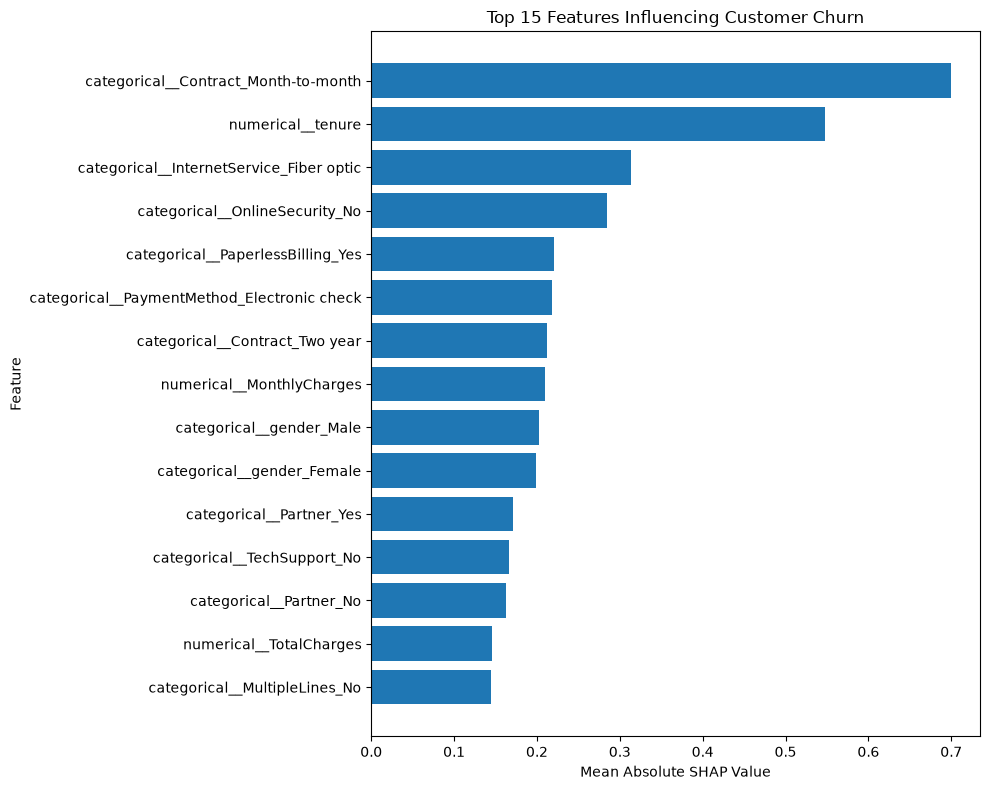

In [7]:
# ============================================
# TOP 15 SHAP FEATURE IMPORTANCE PLOT
# ============================================

# Select top 15 features
top_15_features = shap_importance_df.head(15).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=True
)

# Create horizontal bar plot
plt.figure(figsize=(10, 8))

plt.barh(
    top_15_features["Feature"],
    top_15_features["Mean_Absolute_SHAP"]
)

# Add title and labels
plt.title("Top 15 Features Influencing Customer Churn")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

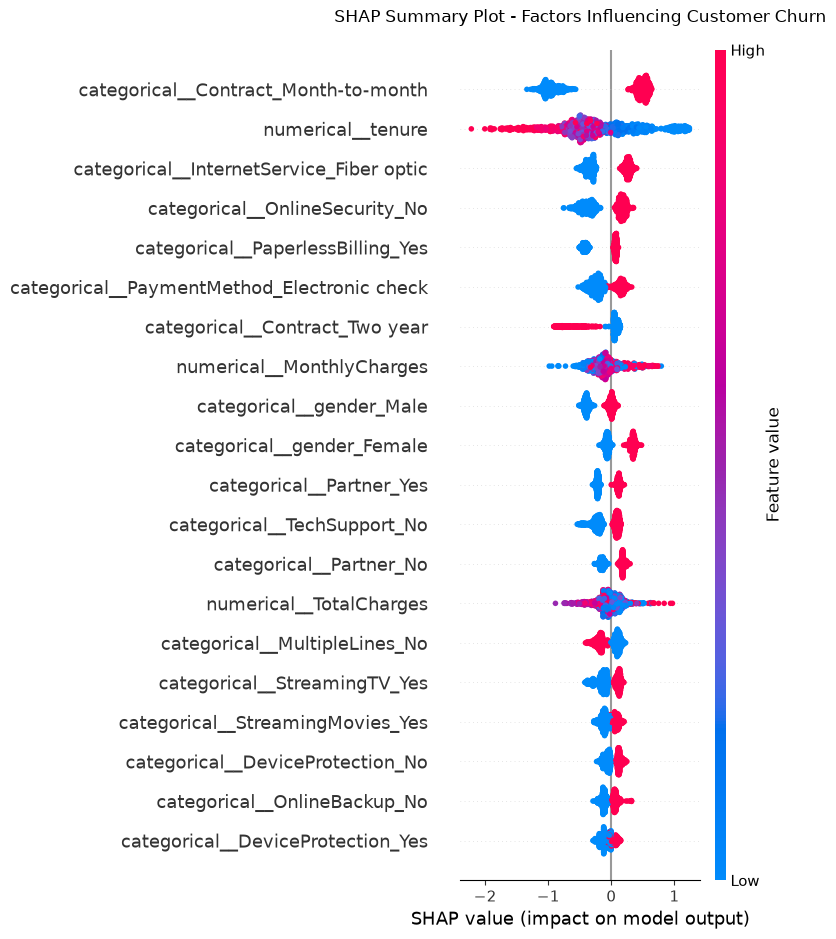

In [8]:
# ============================================
# SHAP SUMMARY BEESWARM PLOT
# ============================================

# Handle different SHAP API output formats
if isinstance(shap_values, list):
    # Binary classification: select SHAP values for Churn = 1
    shap_values_plot = shap_values[1]

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Select SHAP values for Churn = 1
    shap_values_plot = shap_values[:, :, 1]

else:
    shap_values_plot = shap_values

# Create SHAP summary beeswarm plot
shap.summary_plot(
    shap_values_plot,
    X_test_processed,
    feature_names=feature_names,
    max_display=20,
    show=False
)

# Add title
plt.title(
    "SHAP Summary Plot - Factors Influencing Customer Churn",
    pad=20
)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

In [9]:
# ============================================
# INDIVIDUAL CUSTOMER SHAP EXPLANATION
# ============================================

# Select the first customer using index position 0
customer_index = 0

# Keep customer data as a single-row DataFrame
if isinstance(X_test_processed, pd.DataFrame):
    customer_data = X_test_processed.iloc[[customer_index]]
else:
    customer_data = pd.DataFrame(
        X_test_processed[customer_index:customer_index + 1],
        columns=feature_names
    )

# Extract SHAP values for the selected customer
customer_shap_values = shap_values[customer_index]

# Convert SHAP values to a Series with feature names
customer_shap_values = pd.Series(
    customer_shap_values,
    index=feature_names,
    name="SHAP_Value"
)

# Get actual churn label
actual_churn_label = y_test.iloc[customer_index] if hasattr(y_test, "iloc") else y_test[customer_index]

# ============================================
# Display Customer Information
# ============================================

print("=" * 60)
print("INDIVIDUAL CUSTOMER SHAP EXPLANATION")
print("=" * 60)

print("\nCustomer Index:", customer_index)

print("\nProcessed Feature Values:")
print(customer_data.T)

print("\nSHAP Values:")
print(customer_shap_values)

print("\nActual Churn Label:", actual_churn_label)

INDIVIDUAL CUSTOMER SHAP EXPLANATION

Customer Index: 0

Processed Feature Values:
                                                           0
numerical__SeniorCitizen                            2.271100
numerical__tenure                                  -1.037387
numerical__MonthlyCharges                           0.331252
numerical__TotalCharges                            -0.793292
categorical__gender_Female                          0.000000
categorical__gender_Male                            1.000000
categorical__Partner_No                             0.000000
categorical__Partner_Yes                            1.000000
categorical__Dependents_No                          1.000000
categorical__Dependents_Yes                         0.000000
categorical__PhoneService_No                        0.000000
categorical__PhoneService_Yes                       1.000000
categorical__MultipleLines_No                       0.000000
categorical__MultipleLines_No phone service         0.000000
ca

In [10]:
# ============================================
# INDIVIDUAL CUSTOMER CHURN PREDICTION
# ============================================

# Generate churn prediction
customer_prediction = best_xgb_model.predict(customer_data)[0]

# Generate churn probability and extract probability of Churn = 1
customer_churn_probability = best_xgb_model.predict_proba(customer_data)[0, 1]

# Get actual churn label
actual_churn_label = y_test.iloc[customer_index] if hasattr(y_test, "iloc") else y_test[customer_index]

# ============================================
# Display Prediction Results
# ============================================

print("=" * 60)
print("INDIVIDUAL CUSTOMER CHURN PREDICTION")
print("=" * 60)

print(f"\nPredicted Churn Class: {customer_prediction}")
print(f"Churn Probability: {customer_churn_probability * 100:.2f}%")
print(f"Actual Churn Label: {actual_churn_label}")

INDIVIDUAL CUSTOMER CHURN PREDICTION

Predicted Churn Class: 1
Churn Probability: 85.70%
Actual Churn Label: 0


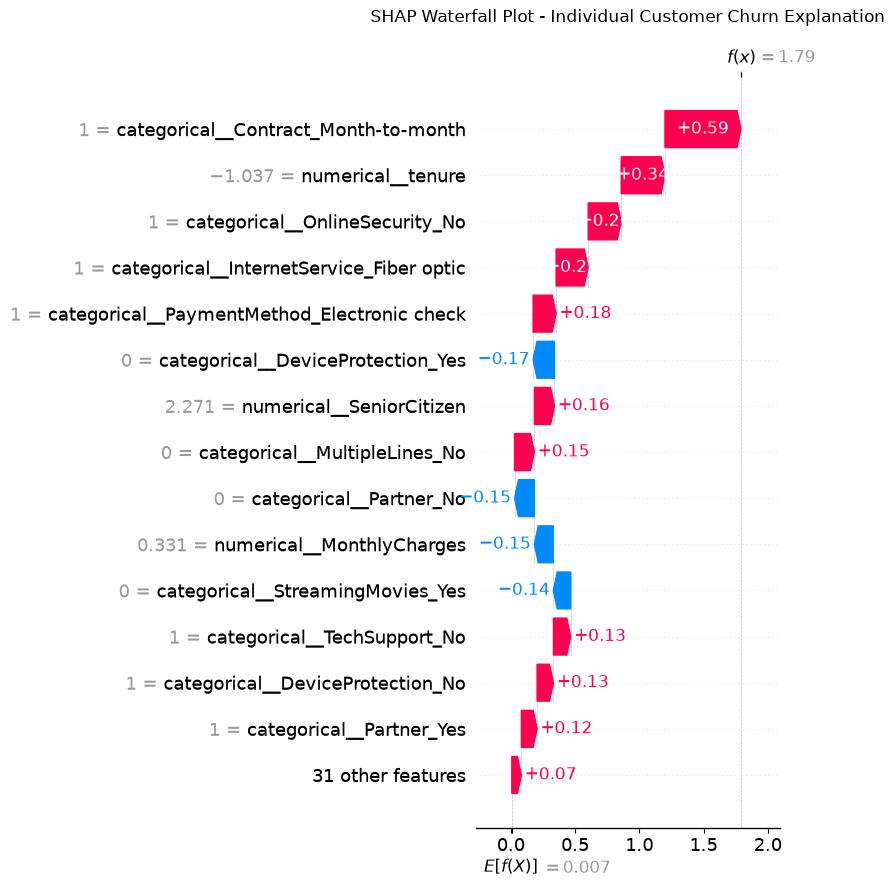

In [11]:
# ============================================
# INDIVIDUAL CUSTOMER SHAP WATERFALL PLOT
# ============================================

# Select customer at index position 0
customer_index = 0

# Keep the selected customer as a single-row DataFrame/array
if isinstance(X_test_processed, pd.DataFrame):
    customer_data = X_test_processed.iloc[[customer_index]]
else:
    customer_data = X_test_processed[customer_index:customer_index + 1]

# Calculate SHAP values for the selected customer
customer_shap_output = shap_explainer(customer_data)

# Handle current SHAP Explanation API
if isinstance(customer_shap_output, shap.Explanation):
    customer_explanation = customer_shap_output[0]

    # Handle multi-output SHAP explanations
    if len(customer_explanation.values.shape) > 1:
        customer_explanation = shap.Explanation(
            values=customer_explanation.values[:, 1],
            base_values=customer_explanation.base_values[:, 1]
            if np.ndim(customer_explanation.base_values) > 0
            else customer_explanation.base_values,
            data=customer_explanation.data,
            feature_names=feature_names
        )
    else:
        customer_explanation.feature_names = feature_names

else:
    # Fallback for older SHAP API
    customer_shap_values = shap_explainer.shap_values(customer_data)

    # Handle list output
    if isinstance(customer_shap_values, list):
        customer_shap_values = customer_shap_values[1]

    # Handle 3D output
    elif isinstance(customer_shap_values, np.ndarray) and customer_shap_values.ndim == 3:
        customer_shap_values = customer_shap_values[:, :, 1]

    # Get expected/base value
    expected_value = shap_explainer.expected_value

    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = np.asarray(expected_value).flatten()[-1]

    # Create SHAP Explanation object
    customer_explanation = shap.Explanation(
        values=customer_shap_values[0],
        base_values=expected_value,
        data=customer_data.iloc[0].values
        if isinstance(customer_data, pd.DataFrame)
        else customer_data[0],
        feature_names=feature_names
    )

# ============================================
# SHAP WATERFALL PLOT
# ============================================

plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    customer_explanation,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Waterfall Plot - Individual Customer Churn Explanation",
    pad=20
)

plt.tight_layout()
plt.show()

In [12]:
# ============================================
# INDIVIDUAL CUSTOMER SHAP EXPLANATION
# ============================================

# Get the customer's feature values
if isinstance(customer_data, pd.DataFrame):
    customer_feature_values = customer_data.iloc[0].values
else:
    customer_feature_values = np.asarray(customer_data)[0]

# Ensure SHAP values are a 1D array
customer_shap_values_array = np.asarray(customer_shap_values).flatten()

# Create explanation DataFrame
customer_explanation_df = pd.DataFrame({
    "Feature": feature_names,
    "Feature_Value": customer_feature_values,
    "SHAP_Value": customer_shap_values_array
})

# Calculate absolute SHAP values
customer_explanation_df["Absolute_SHAP_Value"] = np.abs(
    customer_explanation_df["SHAP_Value"]
)

# Sort by absolute SHAP value in descending order
customer_explanation_df = customer_explanation_df.sort_values(
    by="Absolute_SHAP_Value",
    ascending=False
).reset_index(drop=True)

# ============================================
# TOP 10 FEATURES
# ============================================

print("=" * 70)
print("TOP 10 FEATURES INFLUENCING THIS CUSTOMER'S CHURN PREDICTION")
print("=" * 70)

display(customer_explanation_df.head(10))

# ============================================
# FEATURES INCREASING CHURN RISK
# Positive SHAP values
# ============================================

increasing_churn_risk = customer_explanation_df[
    customer_explanation_df["SHAP_Value"] > 0
].sort_values(
    by="Absolute_SHAP_Value",
    ascending=False
)

print("\n" + "=" * 70)
print("FEATURES INCREASING CHURN RISK")
print("=" * 70)

display(increasing_churn_risk)

# ============================================
# FEATURES DECREASING CHURN RISK
# Negative SHAP values
# ============================================

decreasing_churn_risk = customer_explanation_df[
    customer_explanation_df["SHAP_Value"] < 0
].sort_values(
    by="Absolute_SHAP_Value",
    ascending=False
)

print("\n" + "=" * 70)
print("FEATURES DECREASING CHURN RISK")
print("=" * 70)

display(decreasing_churn_risk)

TOP 10 FEATURES INFLUENCING THIS CUSTOMER'S CHURN PREDICTION


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP_Value
0,categorical__Contract_Month-to-month,1.000000,0.591209,0.591209
1,numerical__tenure,-1.037387,0.340782,0.340782
2,categorical__OnlineSecurity_No,1.000000,0.257118,0.257118
3,categorical__InternetService_Fiber optic,1.000000,0.249485,0.249485
4,categorical__PaymentMethod_Electronic check,1.000000,0.178945,0.178945
5,categorical__DeviceProtection_Yes,0.000000,-0.166458,0.166458
6,numerical__SeniorCitizen,2.271100,0.156591,0.156591
7,categorical__MultipleLines_No,0.000000,0.154070,0.154070
8,categorical__Partner_No,0.000000,-0.153995,0.153995
9,numerical__MonthlyCharges,0.331252,-0.147523,0.147523



FEATURES INCREASING CHURN RISK


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP_Value
0,categorical__Contract_Month-to-month,1.000000,0.591209,0.591209
1,numerical__tenure,-1.037387,0.340782,0.340782
2,categorical__OnlineSecurity_No,1.000000,0.257118,0.257118
3,categorical__InternetService_Fiber optic,1.000000,0.249485,0.249485
4,categorical__PaymentMethod_Electronic check,1.000000,0.178945,0.178945
6,numerical__SeniorCitizen,2.271100,0.156591,0.156591
7,categorical__MultipleLines_No,0.000000,0.154070,0.154070
11,categorical__TechSupport_No,1.000000,0.134338,0.134338
12,categorical__DeviceProtection_No,1.000000,0.127317,0.127317
13,categorical__Partner_Yes,1.000000,0.122229,0.122229



FEATURES DECREASING CHURN RISK


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP_Value
5,categorical__DeviceProtection_Yes,0.000000,-0.166458,0.166458
8,categorical__Partner_No,0.000000,-0.153995,0.153995
9,numerical__MonthlyCharges,0.331252,-0.147523,0.147523
10,categorical__StreamingMovies_Yes,0.000000,-0.135350,0.135350
14,numerical__TotalCharges,-0.793292,-0.120561,0.120561
17,categorical__StreamingTV_Yes,0.000000,-0.083312,0.083312
19,categorical__gender_Female,0.000000,-0.041668,0.041668
22,categorical__OnlineSecurity_Yes,0.000000,-0.029794,0.029794
25,categorical__Contract_One year,0.000000,-0.021706,0.021706
26,categorical__PaymentMethod_Bank transfer (auto...,0.000000,-0.017432,0.017432


In [13]:
# ============================================
# BUSINESS-FRIENDLY INDIVIDUAL CHURN EXPLANATION
# ============================================

# Get top 3 features increasing churn risk
top_3_increasing = customer_explanation_df[
    customer_explanation_df["SHAP_Value"] > 0
].sort_values(
    by="Absolute_SHAP_Value",
    ascending=False
).head(3)

# Get top 3 features decreasing churn risk
top_3_decreasing = customer_explanation_df[
    customer_explanation_df["SHAP_Value"] < 0
].sort_values(
    by="Absolute_SHAP_Value",
    ascending=False
).head(3)

# ============================================
# PRINT BUSINESS-FRIENDLY EXPLANATION
# ============================================

print("=" * 70)
print("INDIVIDUAL CUSTOMER CHURN EXPLANATION")
print("=" * 70)

print(
    f"\nCustomer Churn Probability: "
    f"{customer_churn_probability * 100:.2f}%"
)

print("\nHow to interpret the explanation:")
print(
    "Positive SHAP values push the prediction toward churn, "
    "indicating factors that increase the customer's churn risk."
)
print(
    "Negative SHAP values push the prediction toward non-churn, "
    "indicating factors that reduce the customer's churn risk."
)

print("\n" + "-" * 70)
print("TOP 3 FACTORS INCREASING CHURN RISK")
print("-" * 70)

if len(top_3_increasing) > 0:
    for _, row in top_3_increasing.iterrows():
        print(
            f"• {row['Feature']}: "
            f"Feature value = {row['Feature_Value']}, "
            f"SHAP impact = +{row['SHAP_Value']:.4f}"
        )
else:
    print("No features with a positive SHAP impact were identified.")

print("\n" + "-" * 70)
print("TOP 3 FACTORS DECREASING CHURN RISK")
print("-" * 70)

if len(top_3_decreasing) > 0:
    for _, row in top_3_decreasing.iterrows():
        print(
            f"• {row['Feature']}: "
            f"Feature value = {row['Feature_Value']}, "
            f"SHAP impact = {row['SHAP_Value']:.4f}"
        )
else:
    print("No features with a negative SHAP impact were identified.")

print("\n" + "=" * 70)
print("BUSINESS SUMMARY")
print("=" * 70)

if customer_churn_probability >= 0.5:
    print(
        "The model predicts that this customer is at higher risk of churn. "
        "The factors listed under 'increasing churn risk' are the strongest "
        "contributors pushing the prediction toward churn."
    )
else:
    print(
        "The model predicts that this customer is at lower risk of churn. "
        "The factors listed under 'decreasing churn risk' are the strongest "
        "contributors pushing the prediction toward non-churn."
    )

print(
    "\nThis explanation is based entirely on the model's calculated SHAP values "
    "and the customer's feature information."
)

INDIVIDUAL CUSTOMER CHURN EXPLANATION

Customer Churn Probability: 85.70%

How to interpret the explanation:
Positive SHAP values push the prediction toward churn, indicating factors that increase the customer's churn risk.
Negative SHAP values push the prediction toward non-churn, indicating factors that reduce the customer's churn risk.

----------------------------------------------------------------------
TOP 3 FACTORS INCREASING CHURN RISK
----------------------------------------------------------------------
• categorical__Contract_Month-to-month: Feature value = 1.0, SHAP impact = +0.5912
• numerical__tenure: Feature value = -1.0373874780907992, SHAP impact = +0.3408
• categorical__OnlineSecurity_No: Feature value = 1.0, SHAP impact = +0.2571

----------------------------------------------------------------------
TOP 3 FACTORS DECREASING CHURN RISK
----------------------------------------------------------------------
• categorical__DeviceProtection_Yes: Feature value = 0.0, SHA

In [14]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    shap_values,
    "models/shap_values.pkl"
)

print("SHAP values saved successfully!")
print("SHAP values shape:", np.asarray(shap_values).shape)

SHAP values saved successfully!
SHAP values shape: (1405, 45)
